In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from ipywidgets import interact, FloatSlider, IntSlider
import ipywidgets as widgets

In [2]:
#ich akzeotiere erstmal w=21

w_57 = 21
A_57 = 1.7e-14

def hufnagel_valley_profile(h, w, A):
    term1 = 0.00594 * (w / 27.0)**2 * (1e-5 * h)**10 * np.exp(-h / 1000.0)
    term2 = 2.7e-16 * np.exp(-h / 1500.0)
    term3 = A * np.exp(-h / 100.0)
    return term1 + term2 + term3

integral = quad(
    lambda h: hufnagel_valley_profile(h, w_57, A_57),
    0,
    500000
)[0]

print(f"Integral: {integral:.3e}")

def fried_parameter(wavelength, zenith_angle):
    k = (2 * np.pi) / wavelength
    sec_zeta = 1.0 / np.cos(zenith_angle)
    return (0.423 * sec_zeta * (k**2) * integral)**(-3/5)

def theta_min(wavelength_nm, zenith_angle_deg):
    wl_m = wavelength_nm * 1e-9
    zenith_rad = np.radians(zenith_angle_deg)

    r0 = fried_parameter(wl_m, zenith_rad)
    theta = wl_m / r0

    return r0, theta

@interact(
    zenith_angle_deg=widgets.IntSlider(
        value=45,
        min=0,
        max=89,
        step=1,
        description='Zenit [°]'
    )
)
def update(zenith_angle_deg):
    r0, theta = theta_min(1064, zenith_angle_deg)

    print(f"Zenitwinkel: {zenith_angle_deg}°")
    print(f"r₀ = {r0:.3f} m")
    print(f"θ_min = {theta:.3e} rad ({theta*1e6:.2f} µrad)")

Integral: 6.472e-13


interactive(children=(IntSlider(value=45, description='Zenit [°]', max=89), Output()), _dom_classes=('widget-i…

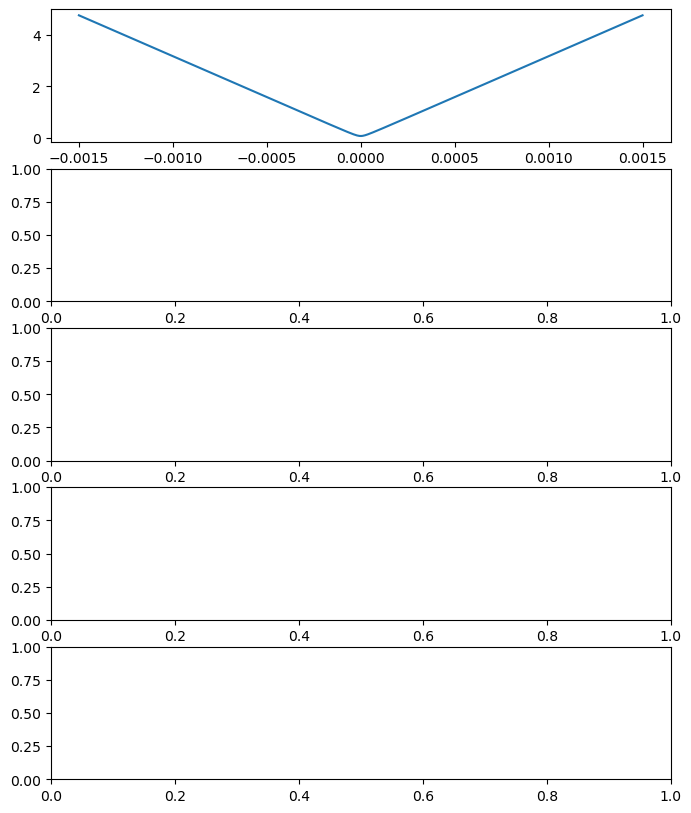

In [3]:
#mein l ist s bei paul
wavelength=1063 *1e-9
f=36.6*1e-3

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(8, 10))
delta= np.linspace(-1.5, 1.5, 1000) *1e-3
MFD = (6.4 + 5.3) / 2 * 1e-6  #from fiber
w0 = MFD / 2   


zR = np.pi * w0**2 / wavelength
    
#w0_n = f * w0 / np.sqrt((f - l)**2 + zR**2)
w0_n = f * w0 / np.sqrt((delta)**2 + zR**2)


zR_n = np.pi * w0_n**2 / wavelength
    

#w_n = w0_n * np.sqrt(1 + (z_km * 1e3 / zR_n)**2)

theta_n = wavelength / (np.pi * w0_n)

ax1.plot(delta, theta_n * 1e3)
#ax1.get_xlabel("delta =s-f [mm]")
#ax1.get_ylabel("theta_n [mrad]")
plt.show()